<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana5/Exemplo_M%C3%A3o_Real.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FINE-TUNING COM VALIDAÇÃO, GRÁFICOS E MÉTRICAS
-> Total de imagens: 140
-> Treino: 112 | Validação: 28

-> Iniciando Treinamento...
Epoch 1/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 467ms/step - accuracy: 0.4018 - loss: 2.4183 - val_accuracy: 0.2857 - val_loss: 1.0984
Epoch 2/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 351ms/step - accuracy: 0.4196 - loss: 1.0774 - val_accuracy: 0.4286 - val_loss: 1.0889
Epoch 3/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 464ms/step - accuracy: 0.4286 - loss: 1.0400 - val_accuracy: 0.4286 - val_loss: 1.0871
Epoch 4/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 406ms/step - accuracy: 0.5357 - loss: 1.0170 - val_accuracy: 0.4286 - val_loss: 1.2159
Epoch 5/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 402ms/step - accuracy: 0.6607 - loss: 0.8771 - val_accuracy: 0.4286 - val_loss: 1.8700
Epoch 6/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 368ms/step - accuracy: 0.6786 - loss: 0.7568 - val_accuracy: 0.4286 - val_loss: 3.6257
Epoch 7/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 478ms/step - accuracy: 0.7946 - loss: 0.5107 - val_accurac

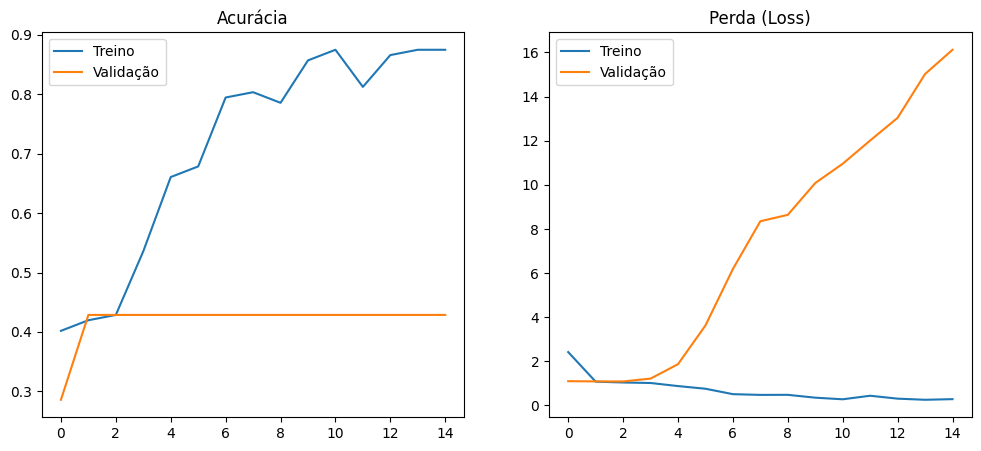


-> Avaliando com Matriz de Confusão e Report:


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       Pedra       0.00      0.00      0.00         8
       Papel       0.43      1.00      0.60        12
     Tesoura       0.00      0.00      0.00         8

    accuracy                           0.43        28
   macro avg       0.14      0.33      0.20        28
weighted avg       0.18      0.43      0.26        28



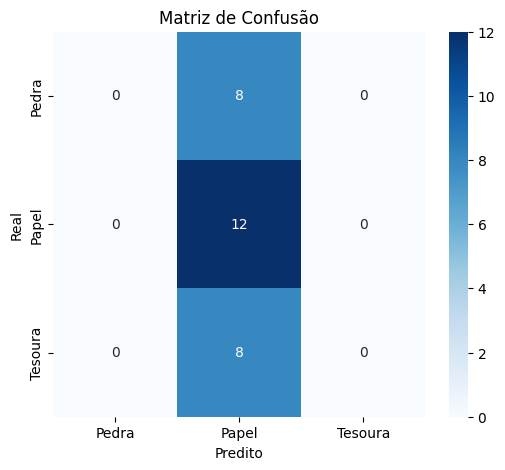

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("="*75)
print("FINE-TUNING COM VALIDAÇÃO, GRÁFICOS E MÉTRICAS")
print("="*75)

# ==============================================================================
# 1. CARREGAMENTO DOS DADOS LOCAIS
# ==============================================================================
fotos_reais = [
    "WhatsApp Image 2026-08-27 at 15.00.58.jpeg", # 0: Pedra
    "WhatsApp Image 2026-08-27 at 15.01.08.jpeg", # 0: Pedra
    "WhatsApp Image 2026-08-27 at 15.02.31.jpeg", # 2: Tesoura
    "WhatsApp Image 2026-08-27 at 15.02.45.jpeg", # 2: Tesoura
    "WhatsApp Image 2026-08-27 at 15.02.57.jpeg", # 1: Papel
    "WhatsApp Image 2026-08-27 at 15.03.06.jpeg", # 1: Papel
    "WhatsApp Image 2026-08-27 at 15.03.26.jpeg"  # 1: Papel
]
gabaritos = [0, 0, 2, 2, 1, 1, 1]
nomes_classes = ['Pedra', 'Papel', 'Tesoura']

imagens_professor = []
for nome in fotos_reais:
    if not os.path.exists(nome):
        print(f"[ERRO] Faça o upload da foto: {nome}")
        continue
    img = tf.keras.utils.load_img(nome, target_size=(150, 150))
    imagens_professor.append(tf.keras.utils.img_to_array(img))

x_treino_base = np.array(imagens_professor)
y_treino_base = np.array(gabaritos)

# ==============================================================================
# 2. EXPANSÃO E DIVISÃO (TREINO / VALIDAÇÃO)
# ==============================================================================
fator_multiplicacao = 20
x_expandido = np.concatenate([x_treino_base] * fator_multiplicacao)
y_expandido = np.concatenate([y_treino_base] * fator_multiplicacao)

# Separando 20% para validação real
x_train, x_val, y_train, y_val = train_test_split(
    x_expandido, y_expandido, test_size=0.2, random_state=42, stratify=y_expandido
)

print(f"-> Total de imagens: {len(x_expandido)}")
print(f"-> Treino: {len(x_train)} | Validação: {len(x_val)}")

# ==============================================================================
# 3. CONSTRUINDO A CNN
# ==============================================================================
modelo_finetuning = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150, 150, 3)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

modelo_finetuning.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ==============================================================================
# 4. AUGMENTATION E TREINAMENTO
# ==============================================================================
gerador = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, fill_mode='nearest'
)

print("\n-> Iniciando Treinamento...")
historico = modelo_finetuning.fit(
    gerador.flow(x_train, y_train, batch_size=8),
    validation_data=(x_val/255.0, y_val), # Validação precisa do rescale manual se não estiver no gerador
    epochs=15, verbose=1
)

# ==============================================================================
# 5. GRÁFICOS DE DESEMPENHO
# ==============================================================================
acc = historico.history['accuracy']
val_acc = historico.history['val_accuracy']
loss = historico.history['loss']
val_loss = historico.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Treino')
plt.plot(val_acc, label='Validação')
plt.title('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Treino')
plt.plot(val_loss, label='Validação')
plt.title('Perda (Loss)')
plt.legend()
plt.show()

# ==============================================================================
# 6. MÉTRICAS E MATRIZ DE CONFUSÃO
# ==============================================================================
print("\n-> Avaliando com Matriz de Confusão e Report:")
y_pred_prob = modelo_finetuning.predict(x_val/255.0, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_val, y_pred, target_names=nomes_classes))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=nomes_classes, yticklabels=nomes_classes, cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()